# PRCL-0017 - NO CHURN Telecom
### Business Case:
- No-Churn Telecom is an established Telecom operator in Europe with more than a decade in Business. Due to new players in the market, telecom industry has become very competitive and retaining customers becoming a challenge.
- In spite of No-Churn initiatives of reducing tariffs and promoting more offers, the churn rate ( percentage of customers migrating to competitors) is well above 10%.
- No-Churn wants to explore possibility of Machine Learning to help with following use cases to retain competitive edge in the industry.
### PROJECT GOAL
- Help No-Churn with their use cases with ML
    1. Understanding the variables that are influencing the customers to migrate.
    2. Creating Churn risk scores that can be indicative to drive retention campaigns.
    3. Introduce new predicting variable “CHURN-FLAG” with values YES(1) or NO(0) so that email campaigns with lucrative offers can be targeted to Churn YES customers.

## Installing packages and importing libraries

In [1]:
!pip install pymysql
!pip install mysql_connector

In [2]:
import os
import mysql.connector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Connecting to the host with the database-Loading data

In [3]:
connection = mysql.connector.connect(host='18.136.157.135',user='dm_team3',password='DM!$!Team!27@9!20&',database='project_telecom')

In [4]:
# Querying the table from sql
query = 'Select * from telecom_churn_data'
df = pd.read_sql(query,connection)
df

,columns1,columns2,columns3,columns4,columns5,columns6,columns7,columns8,columns9,columns10,...,columns12,columns13,columns14,columns15,columns16,columns17,columns18,columns19,columns20,columns21
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4612,NY,57,510,345-7512,no,yes,25,144,81,24.48,...,112,15.91,158.6,122,7.14,8.5,6,2.3,3,False.
4613,NM,177,408,343-6820,no,yes,29,189,91,32.13,...,96,25.76,163.6,116,7.36,15.7,1,4.24,3,False.
4614,VT,67,408,338-4794,no,yes,33,127.5,126,21.68,...,129,25.17,200.9,91,9.04,13,3,3.51,1,False.
4615,MI,98,415,355-8388,no,yes,23,168.9,98,28.71,...,117,19.24,165.5,96,7.45,14.3,3,3.86,0,False.


## Renaming the column names as per provided data

In [5]:
df.columns

Index(['columns1', 'columns2', 'columns3', 'columns4', 'columns5', 'columns6',
       'columns7', 'columns8', 'columns9', 'columns10', 'columns11',
       'columns12', 'columns13', 'columns14', 'columns15', 'columns16',
       'columns17', 'columns18', 'columns19', 'columns20', 'columns21'],
      dtype='object')

In [6]:
q = ['State','account_length','area_code','phone','international_plan','vmail_plan','vmail_message','day_mins','day_calls','day_charge','eve_mins','eve_calls','eve_charge','night_mins','night_calls','night_charge','international_mins','international_calls','international_charge','custServ_calls','churn']
df.columns=q

In [7]:
pd.set_option('display.max_columns',None)
df.head()

,State,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,international_mins,international_calls,international_charge,custServ_calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


### Feature descriptions
- State : State of residence of customer
- Account Length : Number of active days
- Area Code : Area code 
- Phone : Phone number
- International Plan : Whether customer has international plan or not
- VMail Plan : Whether customer has voice mail feature or not
- VMail Message : Average number of voice mail messages per month.
- Day Mins : daytime calls duration
- Day Calls : count of daytime calls
- Day Charge : Billing cost of daytime calls
- Eve Mins : evening calls duration
- Eve Calls : count of Evening calls
- Eve Charge : Billing cost for evening calls
- Night Mins : Night calls duration
- Night Calls : count of night calls
- Night Charge : Billing cost for night calls
- International Mins : International calls duration
- International calls : count of international calls
- International Charge : Billing cost for international calls
- CustServ Calls : No. of calls to customer service
- Churn : Whether the customer left the service or not

### Basic checks

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   State                 4617 non-null   object
 1   account_length        4617 non-null   object
 2   area_code             4617 non-null   object
 3   phone                 4617 non-null   object
 4   international_plan    4617 non-null   object
 5   vmail_plan            4617 non-null   object
 6   vmail_message         4617 non-null   object
 7   day_mins              4617 non-null   object
 8   day_calls             4617 non-null   object
 9   day_charge            4617 non-null   object
 10  eve_mins              4617 non-null   object
 11  eve_calls             4617 non-null   object
 12  eve_charge            4617 non-null   object
 13  night_mins            4617 non-null   object
 14  night_calls           4617 non-null   object
 15  night_charge          4617 non-null   

In [9]:
df.isnull().sum()

State                   0
account_length          0
area_code               0
phone                   0
international_plan      0
vmail_plan              0
vmail_message           0
day_mins                0
day_calls               0
day_charge              0
eve_mins                0
eve_calls               0
eve_charge              0
night_mins              0
night_calls             0
night_charge            0
international_mins      0
international_calls     0
international_charge    0
custServ_calls          0
churn                   0
dtype: int64

#### There are no null values

In [10]:
# Changing the numerical columns to float datatype
col = ['account_length','vmail_message','day_mins','day_calls','day_charge','eve_mins','eve_calls','eve_charge','night_mins','night_calls','night_charge','international_mins','international_calls','international_charge','custServ_calls']
for i in col:
    df[i] = df[i].astype('float')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4617 entries, 0 to 4616
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 4617 non-null   object 
 1   account_length        4617 non-null   float64
 2   area_code             4617 non-null   object 
 3   phone                 4617 non-null   object 
 4   international_plan    4617 non-null   object 
 5   vmail_plan            4617 non-null   object 
 6   vmail_message         4617 non-null   float64
 7   day_mins              4617 non-null   float64
 8   day_calls             4617 non-null   float64
 9   day_charge            4617 non-null   float64
 10  eve_mins              4617 non-null   float64
 11  eve_calls             4617 non-null   float64
 12  eve_charge            4617 non-null   float64
 13  night_mins            4617 non-null   float64
 14  night_calls           4617 non-null   float64
 15  night_charge         

In [12]:
df.describe()

,account_length,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,international_mins,international_calls,international_charge,custServ_calls
count,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000,4617.000000
mean,100.645224,7.849903,180.447152,100.054364,30.676576,200.429088,100.179770,17.036703,200.623933,99.944120,9.028185,10.279294,4.433831,2.775926,1.567035
std,39.597194,13.592333,53.983540,19.883027,9.177145,50.557001,19.821314,4.297332,50.543616,19.935053,2.274488,2.757361,2.457615,0.744413,1.307019
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,12.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,0.000000,143.700000,87.000000,24.430000,165.900000,87.000000,14.100000,167.100000,87.000000,7.520000,8.600000,3.000000,2.320000,1.000000
50%,100.000000,0.000000,180.000000,100.000000,30.600000,200.800000,101.000000,17.070000,200.800000,100.000000,9.040000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,17.000000,216.800000,113.000000,36.860000,234.000000,114.000000,19.890000,234.900000,113.000000,10.570000,12.100000,6.000000,3.270000,2.000000
max,243.000000,51.000000,351.500000,165.000000,59.760000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [13]:
df.describe(include='O')

,State,area_code,phone,international_plan,vmail_plan,churn
count,4617,4617,4617,4617,4617,4617
unique,51,3,4617,2,2,2
top,WV,415,382-4657,no,no,False.
freq,149,2299,1,4171,3381,3961


#### Insights:
- There are 51 unique states represented in the dataset.
- Each phone number in the dataset is unique, which indicates that it can be used as a unique identifier for each customer.
- Most of the customers (4171 out of 4617) do not have an international plan.
- A significant number of customers (3381 out of 4617) do not have a voicemail plan.
- There are 3961 customers who did not churn, and only 656 customers churned. This suggests that the dataset may be imbalanced, and some additional analysis may be required to handle this.

## Exploratory Data Analysis

In [14]:
df.select_dtypes(['float']).columns

Index(['account_length', 'vmail_message', 'day_mins', 'day_calls',
       'day_charge', 'eve_mins', 'eve_calls', 'eve_charge', 'night_mins',
       'night_calls', 'night_charge', 'international_mins',
       'international_calls', 'international_charge', 'custServ_calls'],
      dtype='object')

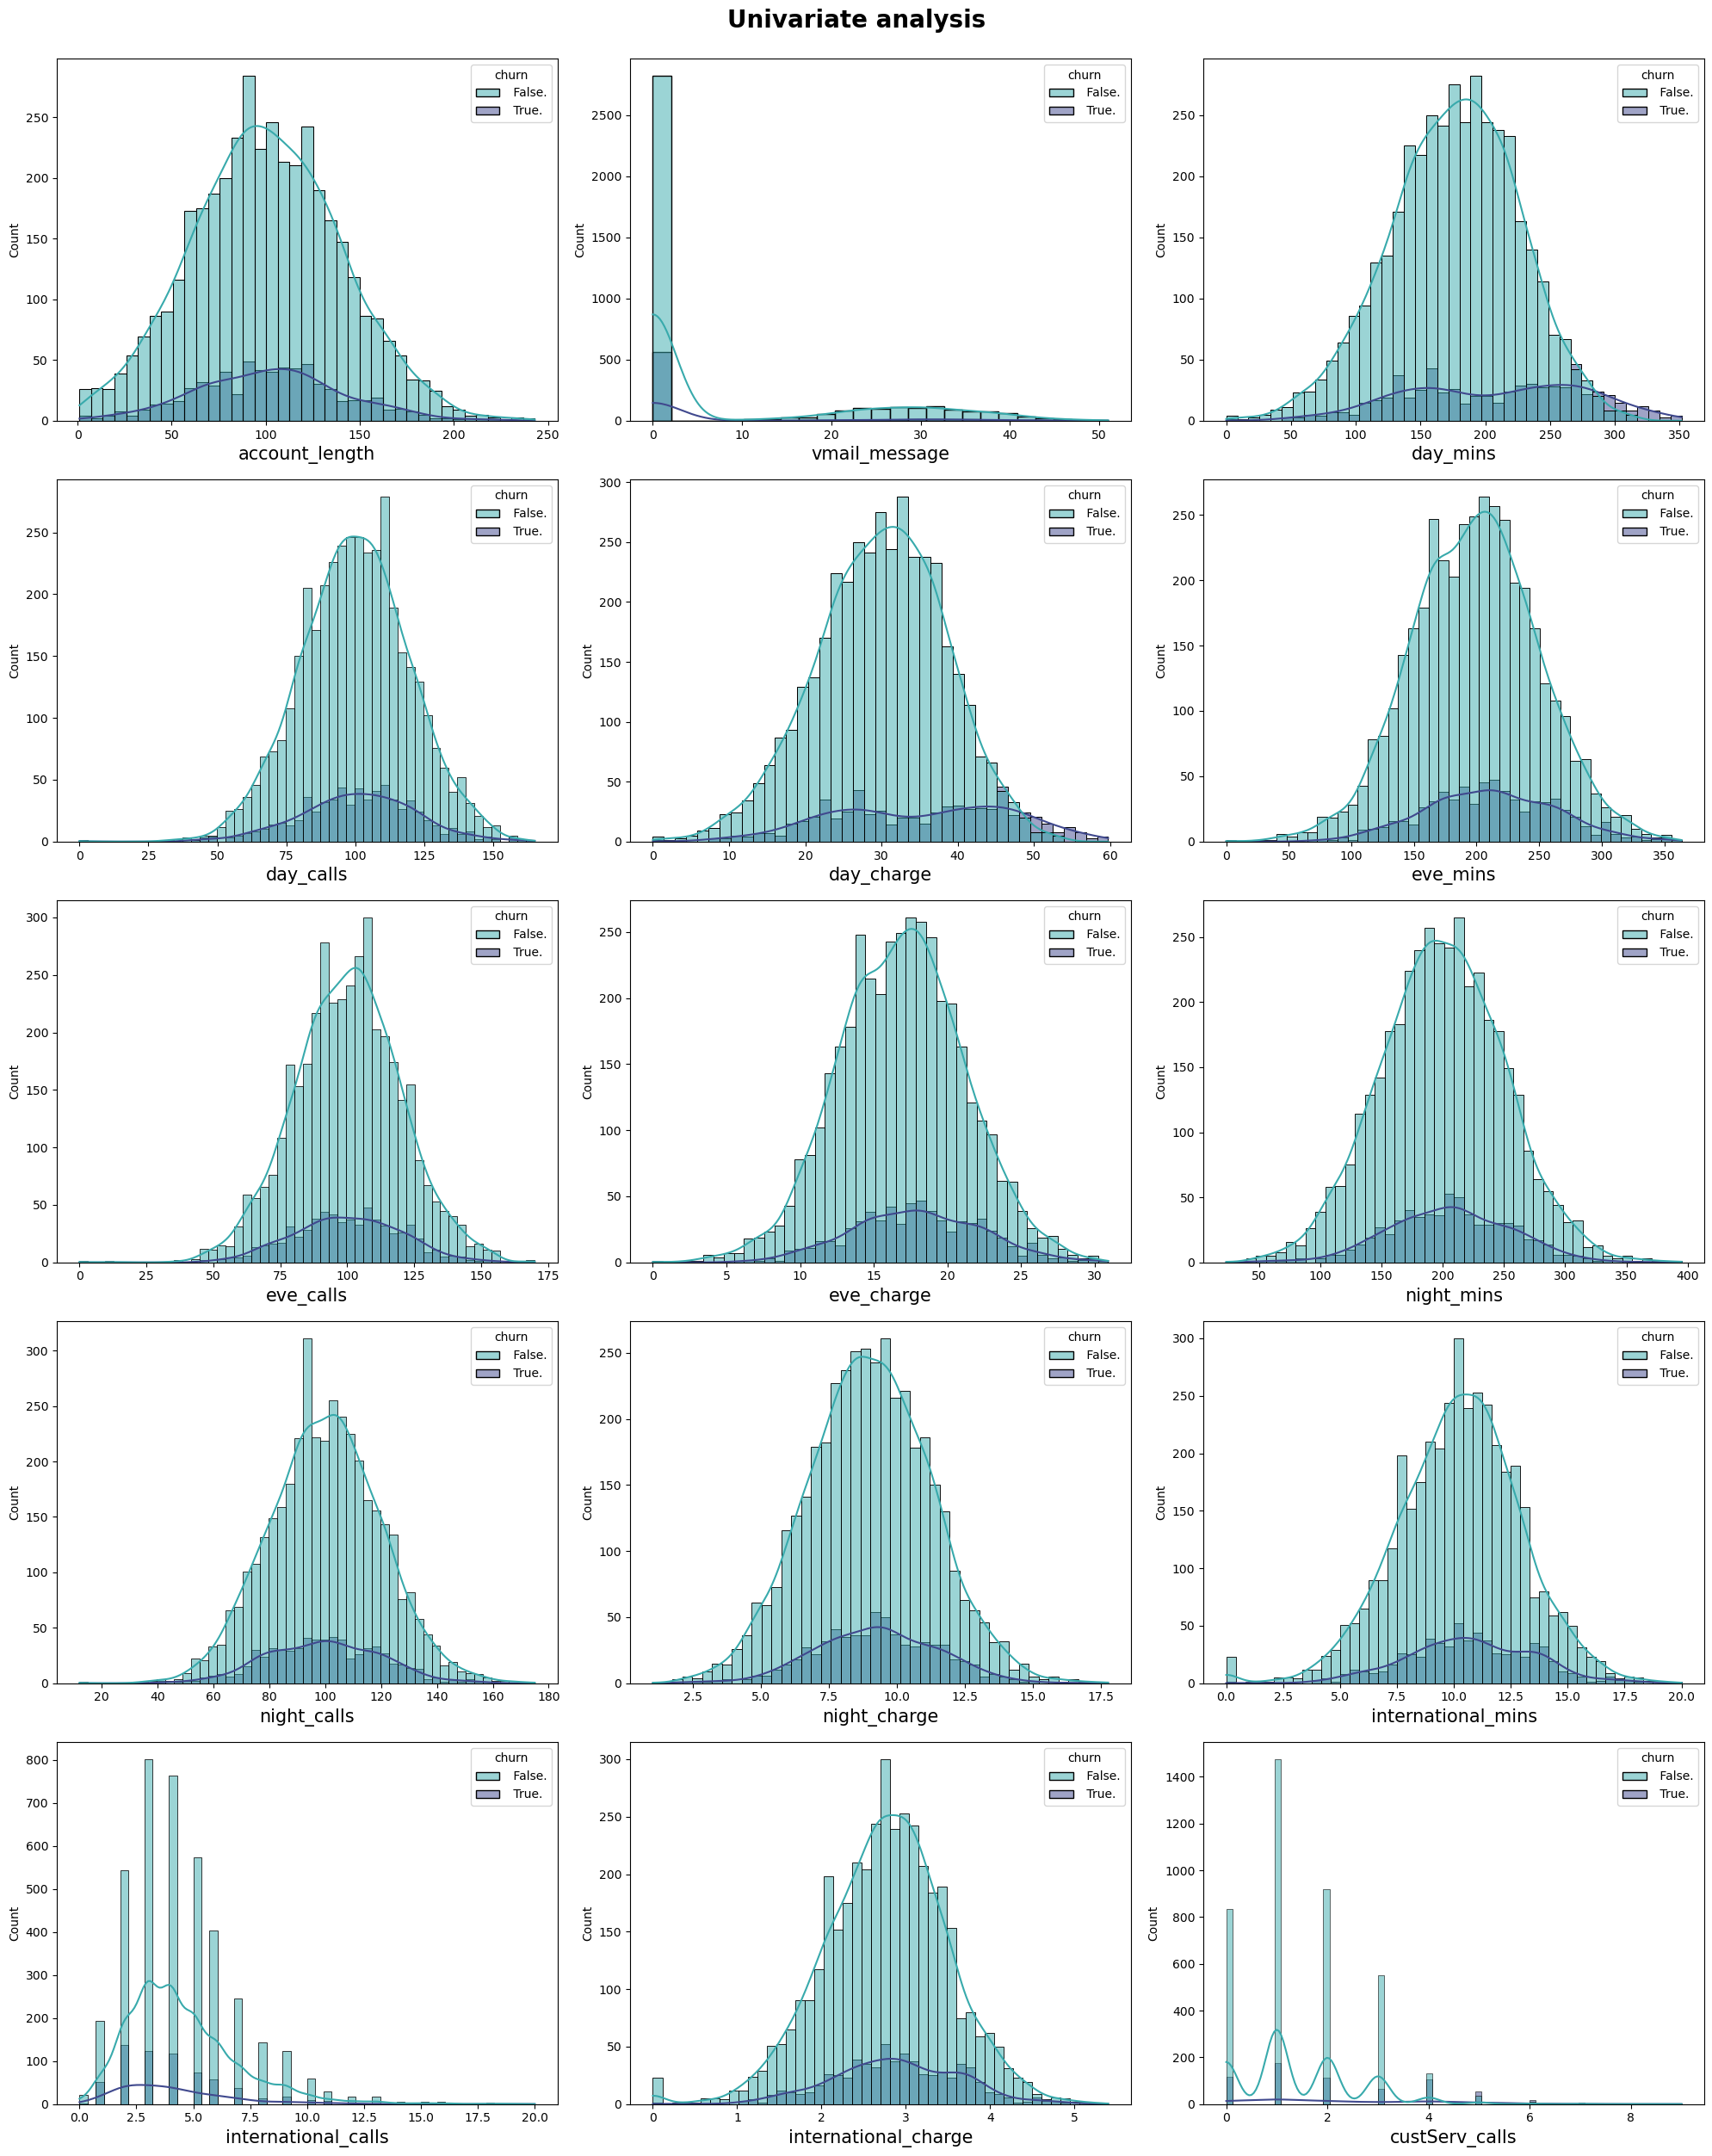

In [15]:
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in df.select_dtypes(['float']).columns:
    if plotnumber<=15:
        ax = plt.subplot(5,3,plotnumber)
        sns.histplot(x=df[column], hue=df['churn'],palette='mako_r',kde=True)
        plt.xlabel(column, fontsize=15)
    plotnumber = plotnumber+1
plt.suptitle("Univariate analysis", fontsize=20, weight='bold', x=0.5, y=1.0)
plt.tight_layout()

In [16]:
df.select_dtypes(['object']).columns

Index(['State', 'area_code', 'phone', 'international_plan', 'vmail_plan',
       'churn'],
      dtype='object')

<Axes: xlabel='State', ylabel='count'>

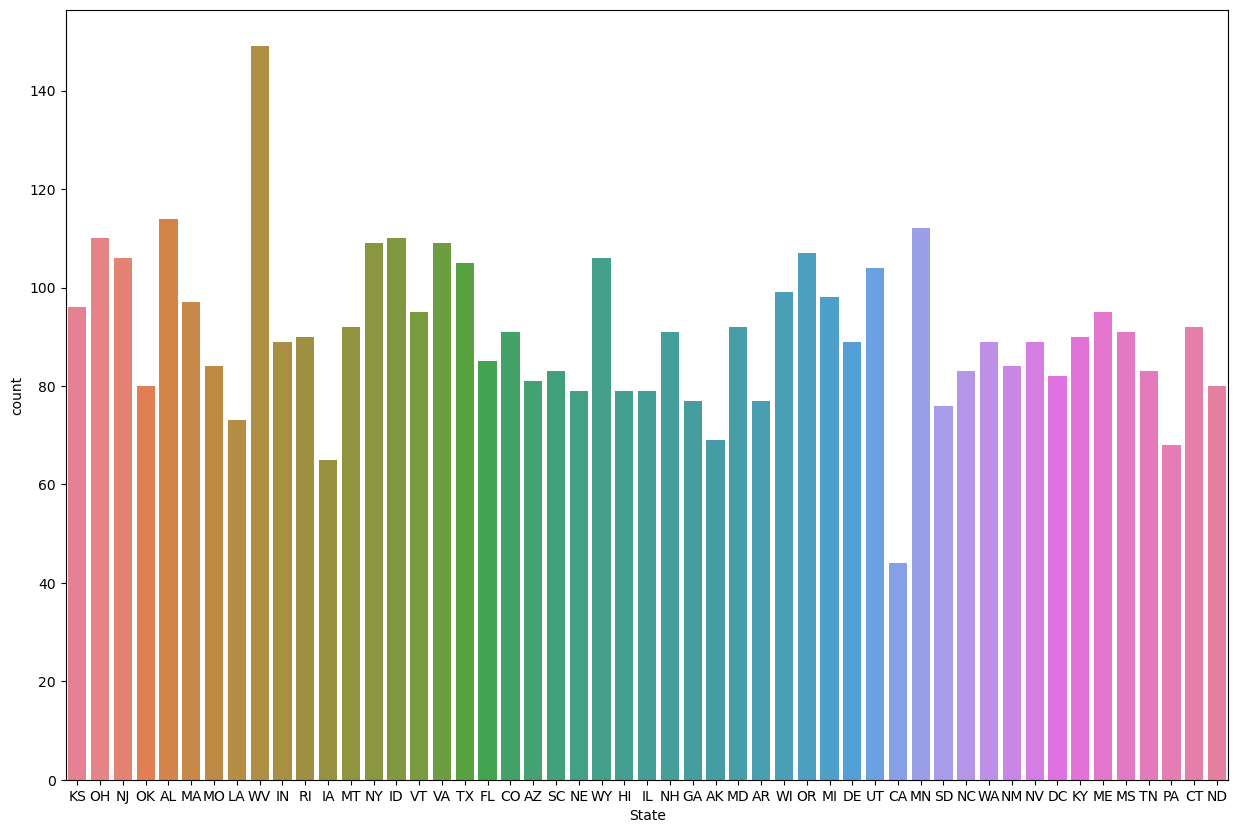

In [17]:
plt.figure(figsize=(15,10))
sns.countplot(x=df['State'], palette='husl')

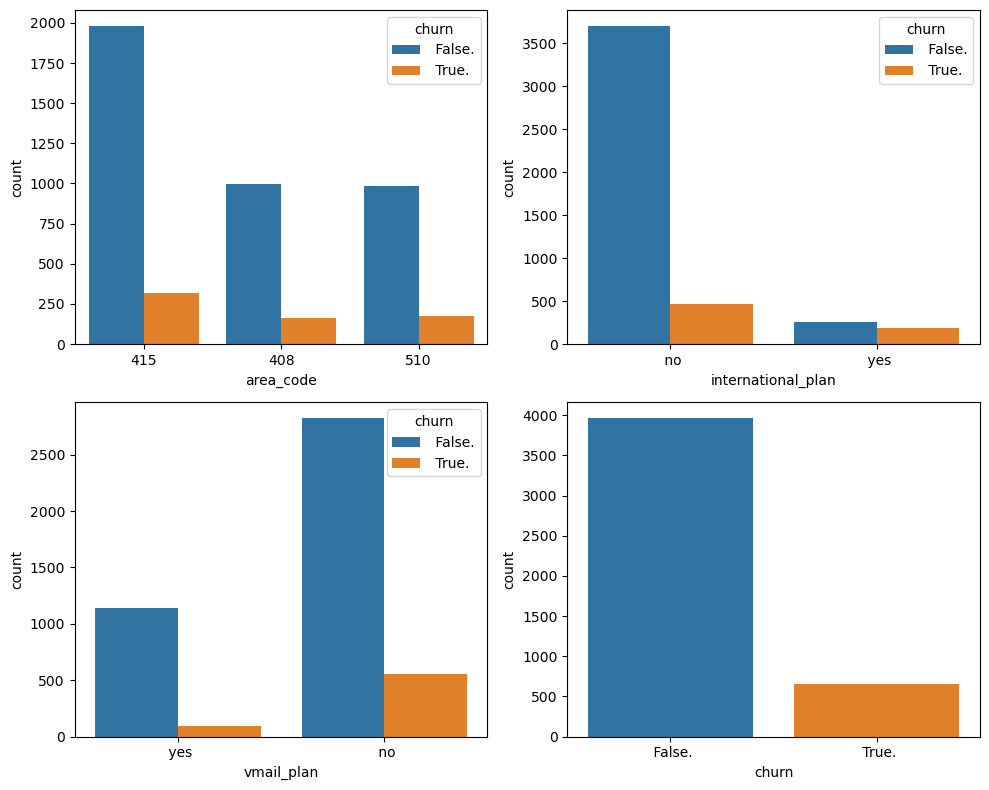

In [18]:
col=['area_code', 'international_plan', 'vmail_plan','churn']
plt.figure(figsize=(10,8))
plotnumber=1
for i in col:
    plt.subplot(2,2,plotnumber)
    sns.countplot(x=df[i], hue=df['churn'])
    plt.xlabel(i)
    plotnumber+=1
plt.tight_layout()
plt.show()

### Account Length and International Plan

<Axes: xlabel='churn', ylabel='account_length'>

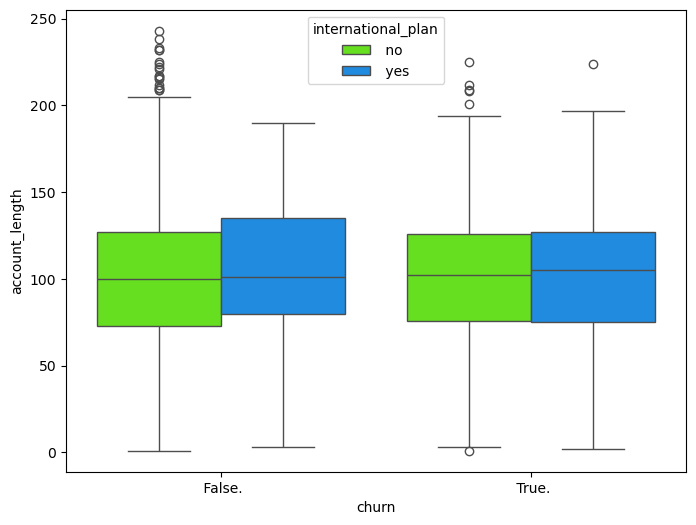

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='churn', y='account_length', hue='international_plan', data=df, palette='gist_rainbow')

- The plot help us to visualize whether the "International Plan" feature has an impact on account length or churn. 
- All the 4 boxplot appeared to almost aligned and having same size. 
- There is also a minimal difference between median values of all the boxplots.
- From the plot suggests that it does not matter whether or not a customer had an international plan, as far as predicting customer churn

### CustService calls with respect to voice-mail plan and international calls

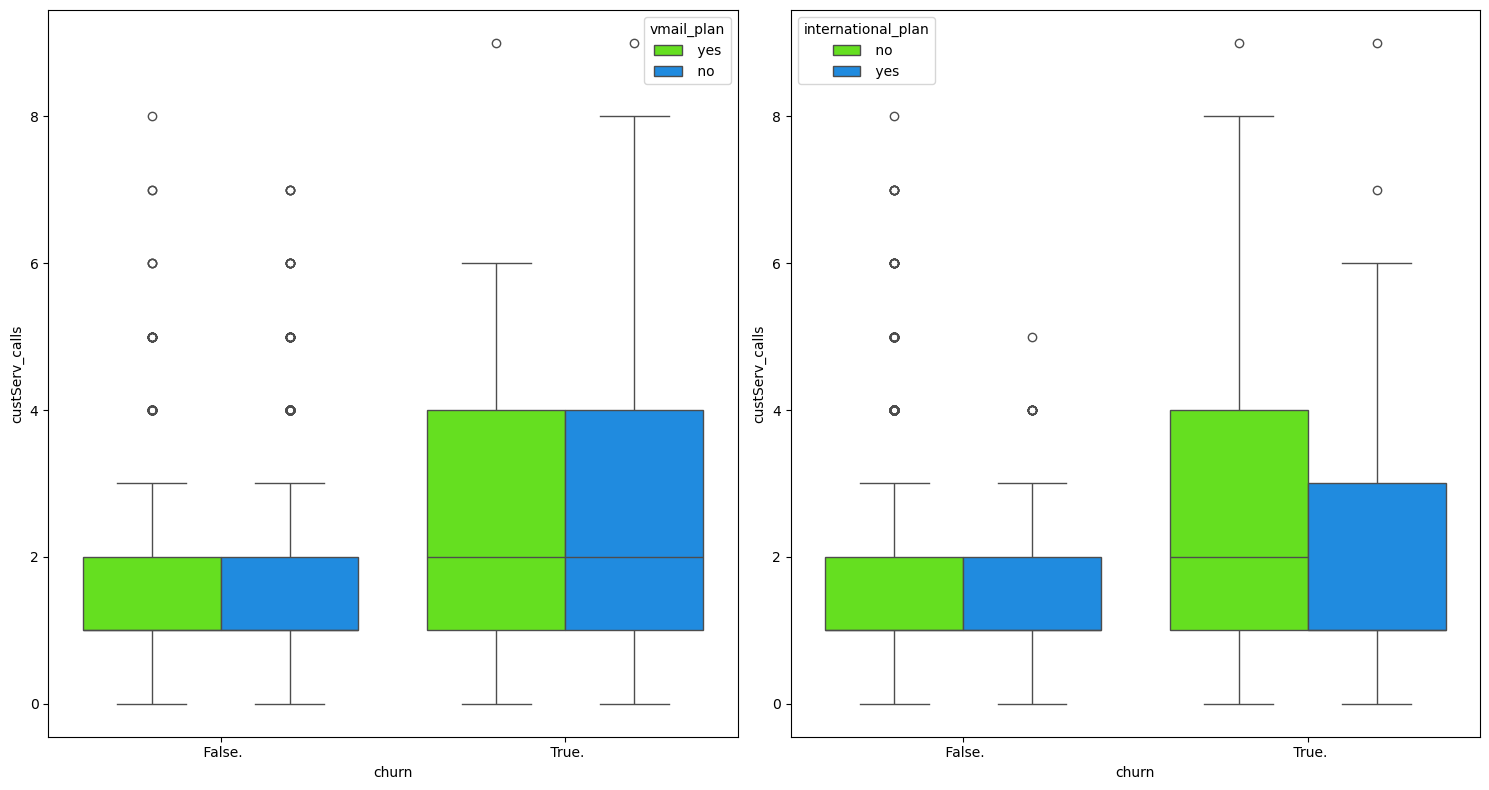

In [20]:
plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
sns.boxplot(x='churn', y='custServ_calls', hue='vmail_plan', data=df, palette='gist_rainbow')

plt.subplot(1,2,2)
sns.boxplot(x='churn', y='custServ_calls', hue='international_plan', data=df, palette='gist_rainbow')
plt.tight_layout()

- Customers who churned (churn=True) made more customer service calls, especially those with and without vmail plans.
- Median and IQR (box height) for churned customers are higher → more complaints or issues.
- Churned customers with no international plans made more customer service calls on average than those with international plans

## Bivariate Analysis

### Mins Vs Charges

In [21]:
df.head()

,State,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,international_mins,international_calls,international_charge,custServ_calls,churn
0,KS,128.0,415,382-4657,no,yes,25.0,265.1,110.0,45.07,197.4,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,False.
1,OH,107.0,415,371-7191,no,yes,26.0,161.6,123.0,27.47,195.5,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,False.
2,NJ,137.0,415,358-1921,no,no,0.0,243.4,114.0,41.38,121.2,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,False.
3,OH,84.0,408,375-9999,yes,no,0.0,299.4,71.0,50.90,61.9,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,False.
4,OK,75.0,415,330-6626,yes,no,0.0,166.7,113.0,28.34,148.3,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,False.


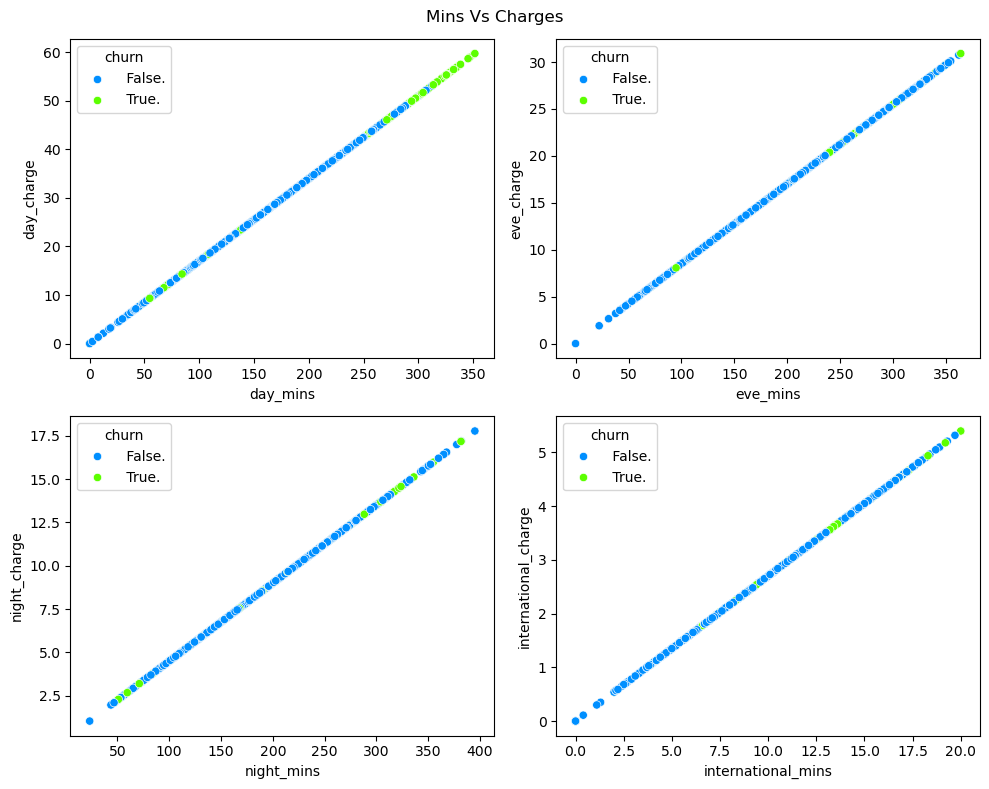

In [22]:
types = ['day', 'eve', 'night', 'international']

fig,ax  =plt.subplots(2,2, figsize=(10,8))

for type , ax in zip(types, ax.flatten()):
    sns.scatterplot(x=type+"_mins", y=type+"_charge", data=df, ax=ax, hue="churn", palette='gist_rainbow_r')

plt.suptitle("Mins Vs Charges")
plt.tight_layout()

- There is a clear positive correlation with the mins and charges. It indicates that more the talking minutes, more the charges.
- Customers who churned and did not churn are all on the same category as there is no particular boundary to differentitate between them as all are equally distributed incase of day and evening charges.
- Usage and billing amounts (for day and evening calls) are not significant churn predictors.
- Incase of night and international mins vs charges, these features don't separate churned from retained users well as they follow the same line with similar spread.

#### Day charge Vs other charges

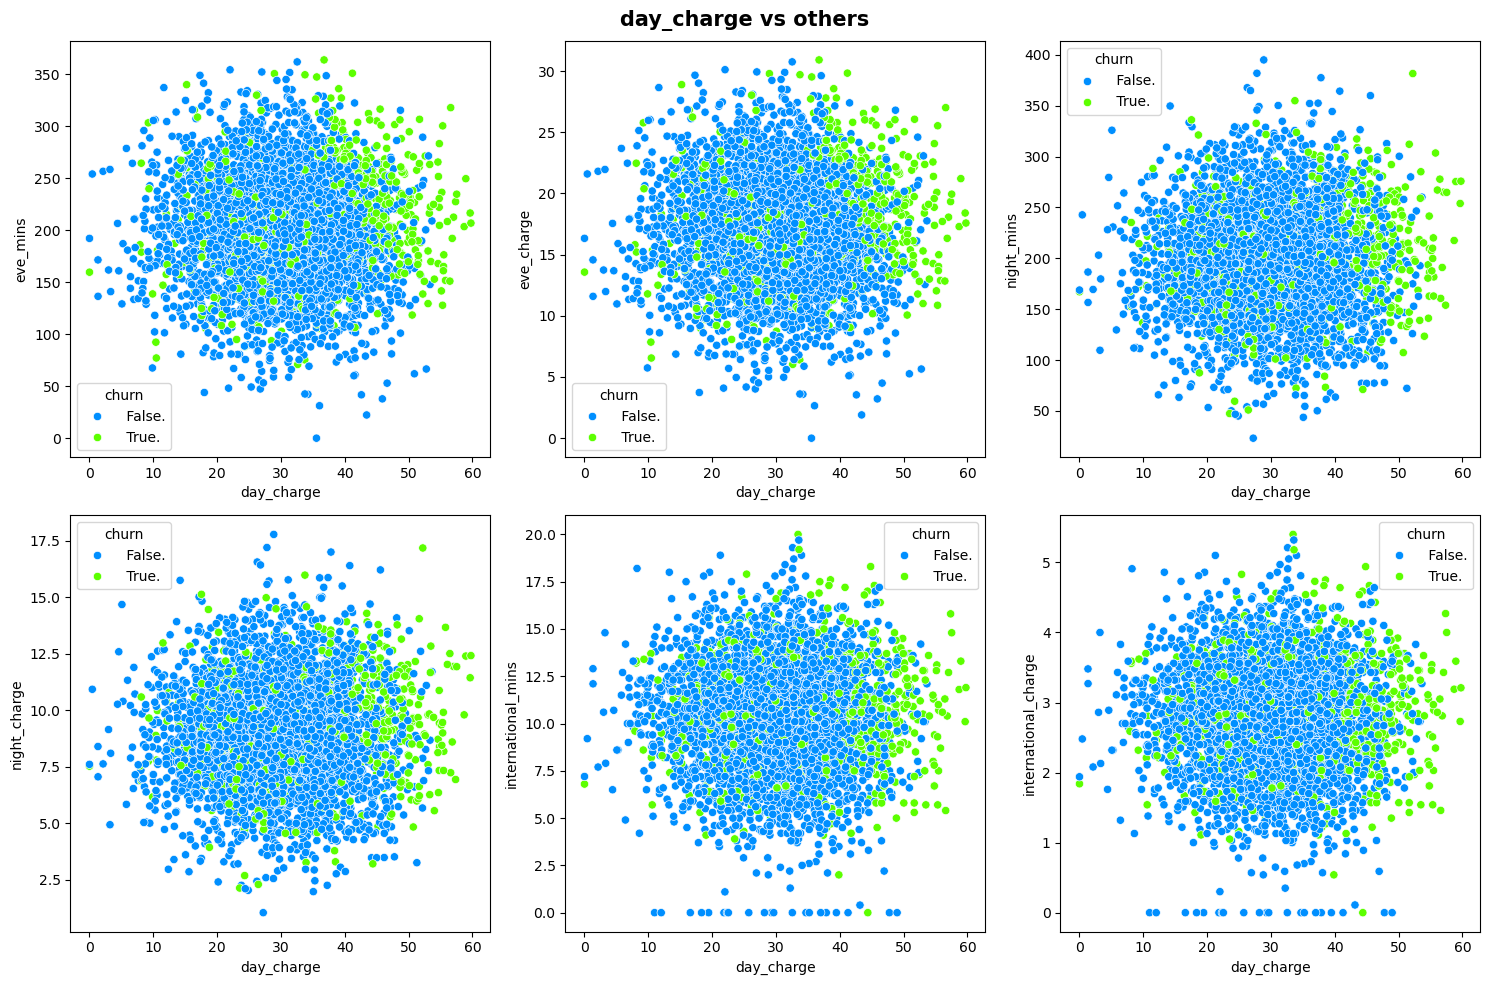

In [23]:
relations =['eve_mins', 'eve_charge', 'night_mins', 'night_charge', 'international_mins', 'international_charge']

fig, ax = plt.subplots(2,3, figsize=(15,10))

for relation, ax in zip(relations, ax.flatten()):
    sns.scatterplot(x='day_charge', y=relation, data=df, ax=ax, hue="churn", palette='gist_rainbow_r')

plt.suptitle('day_charge vs others', fontsize=15, fontweight='bold')
plt.tight_layout()

- From the above plots, color differentiation help us notice that green dots are concentrated on the right side of the plots. This implies, customer switched to competitors had spend more time talking on call during day time and, as a result, paid higher day charge.
- These scatterplot suggest that day charges might be the strong reason for customer churn

#### CustServ calls Vs other charges

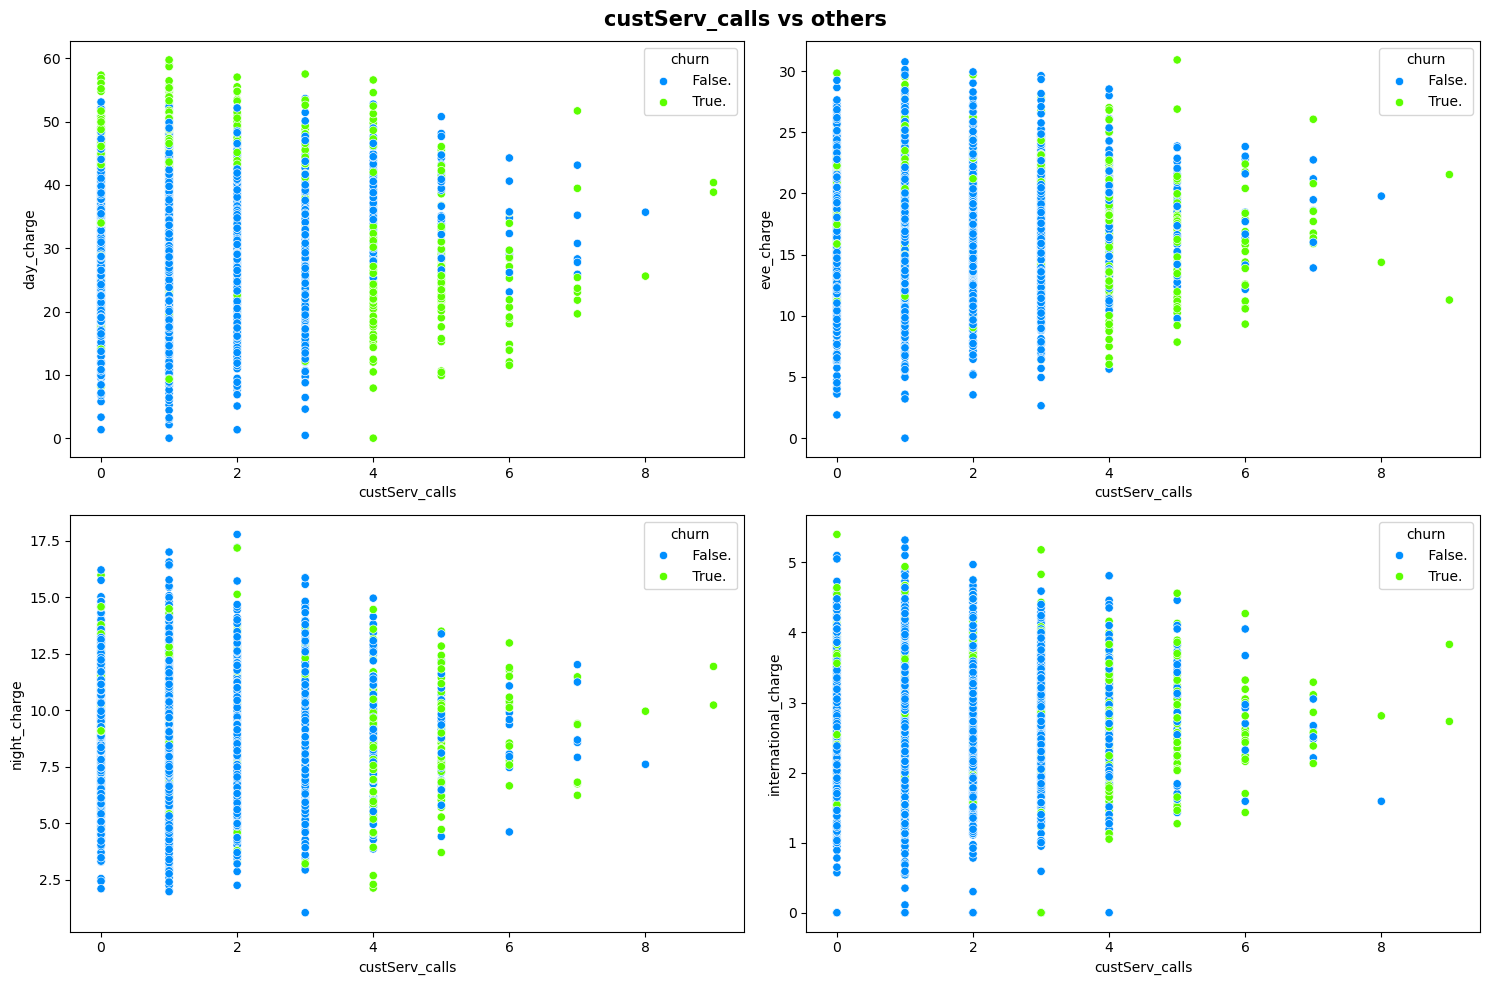

In [24]:
relations=['day_charge', 'eve_charge', 'night_charge', 'international_charge']

fig, ax = plt.subplots(2,2, figsize=(15,10))

for relation, ax in zip(relations, ax.flatten()):
    sns.scatterplot(x='custServ_calls', y=relation, data=df, hue="churn", ax=ax, palette='gist_rainbow_r')

plt.suptitle('custServ_calls vs others', fontsize=15, fontweight='bold')
plt.tight_layout()

- Green dots are crowded on the side where customers had called customer service more number of times.
- Approximately, customers who made 4 or more calls were likey to churn more
- From the first graph, we can see that day charge also contribute in churning of customers as green dots are gathered on the top side as well

In [25]:
df['churn'] = df['churn'].str.strip().str.replace('.', '', regex=False)
print(df['churn'].unique())

['False' 'True']


#### Percentage of Churn Rate Vs International Plan

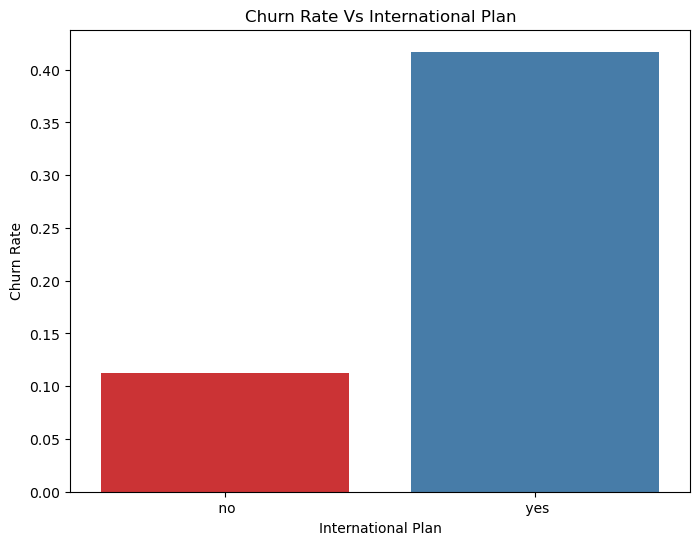

In [26]:
churn_rate = df.groupby('international_plan')['churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8,6))
sns.barplot(x=churn_rate.index, y=churn_rate['True'], palette='Set1')
plt.title('Churn Rate Vs International Plan')
plt.xlabel('International Plan')
plt.ylabel('Churn Rate')
plt.show()

- Customers with an international plan (yes) have a significantly higher churn rate (~42%) compared to those without an international plan (no), whose churn rate is only around 11%.

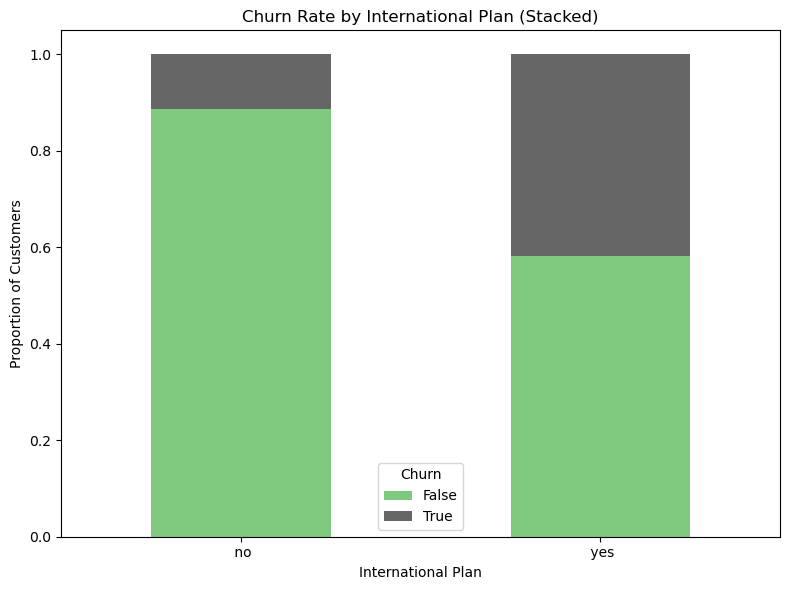

In [27]:
# Group by 'international_plan' and get normalized churn rates
churn_rate = df.groupby('international_plan')['churn'].value_counts(normalize=True).unstack()

# Plot stacked bar chart
churn_rate.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Accent')

# Customize plot
plt.title('Churn Rate by International Plan (Stacked)')
plt.xlabel('International Plan')
plt.ylabel('Proportion of Customers')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Customers without an international plan (no):
- Majority are non-churners (green bar).
- Only a small proportion churned (gray section at the top) indicates higher retention rate in this group.

Customers with an international plan (yes):
- The gray (churned) section is much larger than in the "no" group, indicates higher churn rate among international plan users.



In [28]:
churn_by_state = df[df['churn'] == 'True']['State'].value_counts().sort_values(ascending=False)

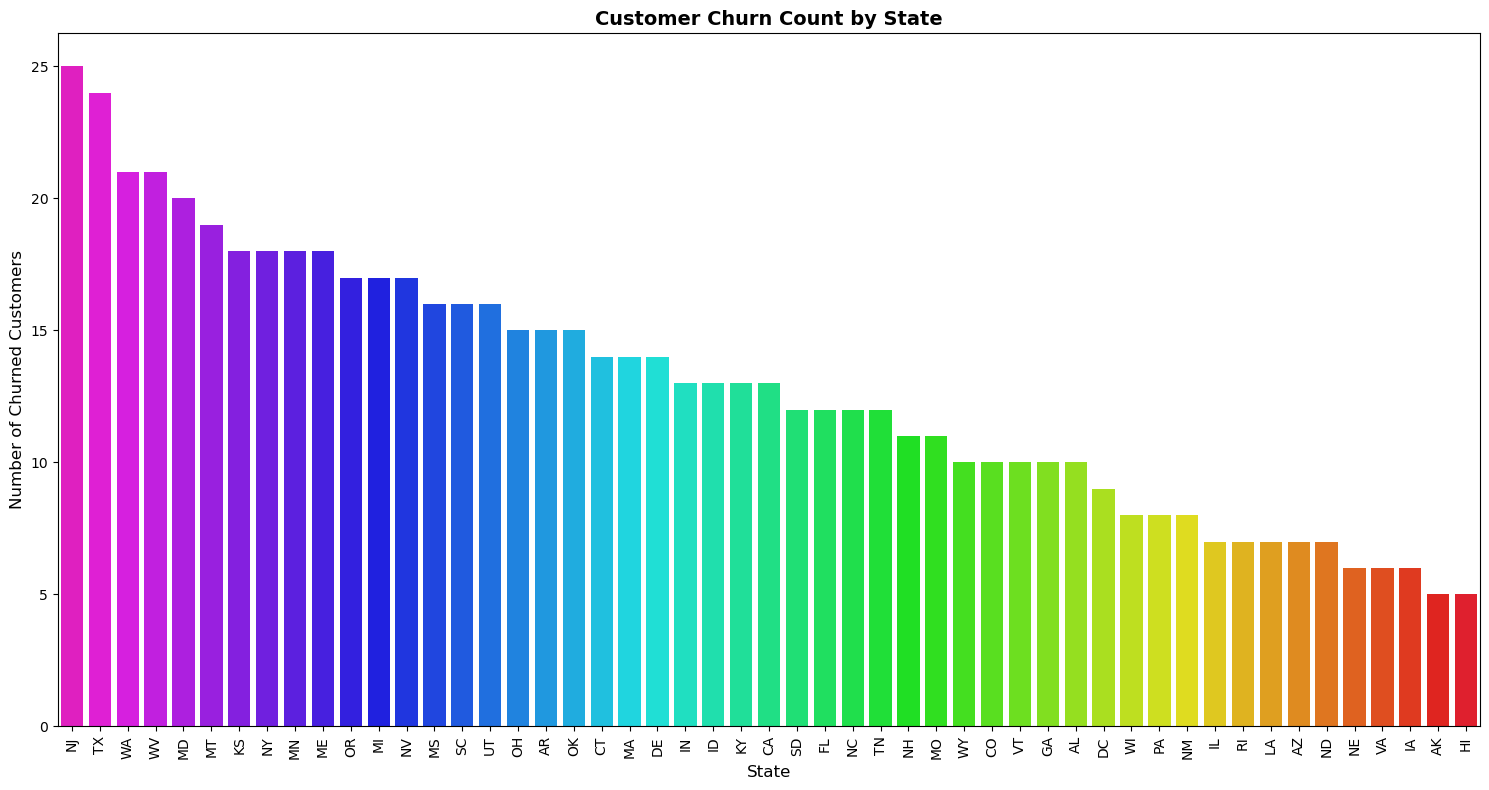

In [29]:
plt.figure(figsize=(15,8))
sns.barplot(x=churn_by_state.index, y=churn_by_state.values, palette='gist_rainbow_r')
plt.title('Customer Churn Count by State', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Churned Customers', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

- NJ (New Jersey), TX (Texas), and VA (Virginia) have the highest number of customer churns.
- States like MT, KS, NY, MN, ME, and OR show moderate churn counts.
- States like HI (Hawaii), AK (Alaska), IA, and VA have the lowest churn.

In [30]:
df.head()

,State,account_length,area_code,phone,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,international_mins,international_calls,international_charge,custServ_calls,churn
0,KS,128.0,415,382-4657,no,yes,25.0,265.1,110.0,45.07,197.4,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,False
1,OH,107.0,415,371-7191,no,yes,26.0,161.6,123.0,27.47,195.5,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,False
2,NJ,137.0,415,358-1921,no,no,0.0,243.4,114.0,41.38,121.2,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,False
3,OH,84.0,408,375-9999,yes,no,0.0,299.4,71.0,50.90,61.9,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,False
4,OK,75.0,415,330-6626,yes,no,0.0,166.7,113.0,28.34,148.3,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,False


### Encoding Categorical Values

In [31]:
df.select_dtypes(include='O').columns

Index(['State', 'area_code', 'phone', 'international_plan', 'vmail_plan',
       'churn'],
      dtype='object')

In [32]:
print(df['international_plan'].unique())
print(df['vmail_plan'].unique())

[' no' ' yes']
[' yes' ' no']


In [33]:
df['international_plan'].value_counts()

international_plan
no     4171
yes     446
Name: count, dtype: int64

In [34]:
df['international_plan'] = df['international_plan'].str.strip().map({'yes': 1, 'no': 0})

In [35]:
df['vmail_plan'].value_counts()

vmail_plan
no     3381
yes    1236
Name: count, dtype: int64

In [36]:
df['vmail_plan'] = df['vmail_plan'].str.strip().map({'yes': 1, 'no': 0})

In [37]:
print(df['churn'].unique())

['False' 'True']


In [38]:
df['churn'] = df['churn'].map({'True': 1, 'False': 0})

#### Dropping irrelevant categorical features

In [39]:
df.drop(['State','area_code','phone'], axis=1, inplace=True)

- State has high cardinality (→ 50+ one-hot columns) which will increase the dimensionality of the dataset. It introduces noise or overfitting risk.
- area_code is often just a numeric region tag, with only 3–4 unique values(few categories), possibly redundant, not behavior-related.
- The phone number is a unique identifier for each customer. It doesn’t carry any predictive information about customer behavior or churn, it adds noise and might mislead the model to pick up on random patterns in phone numbers.

In [40]:
df.head()

,account_length,international_plan,vmail_plan,vmail_message,day_mins,day_calls,day_charge,eve_mins,eve_calls,eve_charge,night_mins,night_calls,night_charge,international_mins,international_calls,international_charge,custServ_calls,churn
0,128.0,0,1,25.0,265.1,110.0,45.07,197.4,99.0,16.78,244.7,91.0,11.01,10.0,3.0,2.70,1.0,0
1,107.0,0,1,26.0,161.6,123.0,27.47,195.5,103.0,16.62,254.4,103.0,11.45,13.7,3.0,3.70,1.0,0
2,137.0,0,0,0.0,243.4,114.0,41.38,121.2,110.0,10.30,162.6,104.0,7.32,12.2,5.0,3.29,0.0,0
3,84.0,1,0,0.0,299.4,71.0,50.90,61.9,88.0,5.26,196.9,89.0,8.86,6.6,7.0,1.78,2.0,0
4,75.0,1,0,0.0,166.7,113.0,28.34,148.3,122.0,12.61,186.9,121.0,8.41,10.1,3.0,2.73,3.0,0


All the categorical columns have been encoded.

### Correlation Heatmap

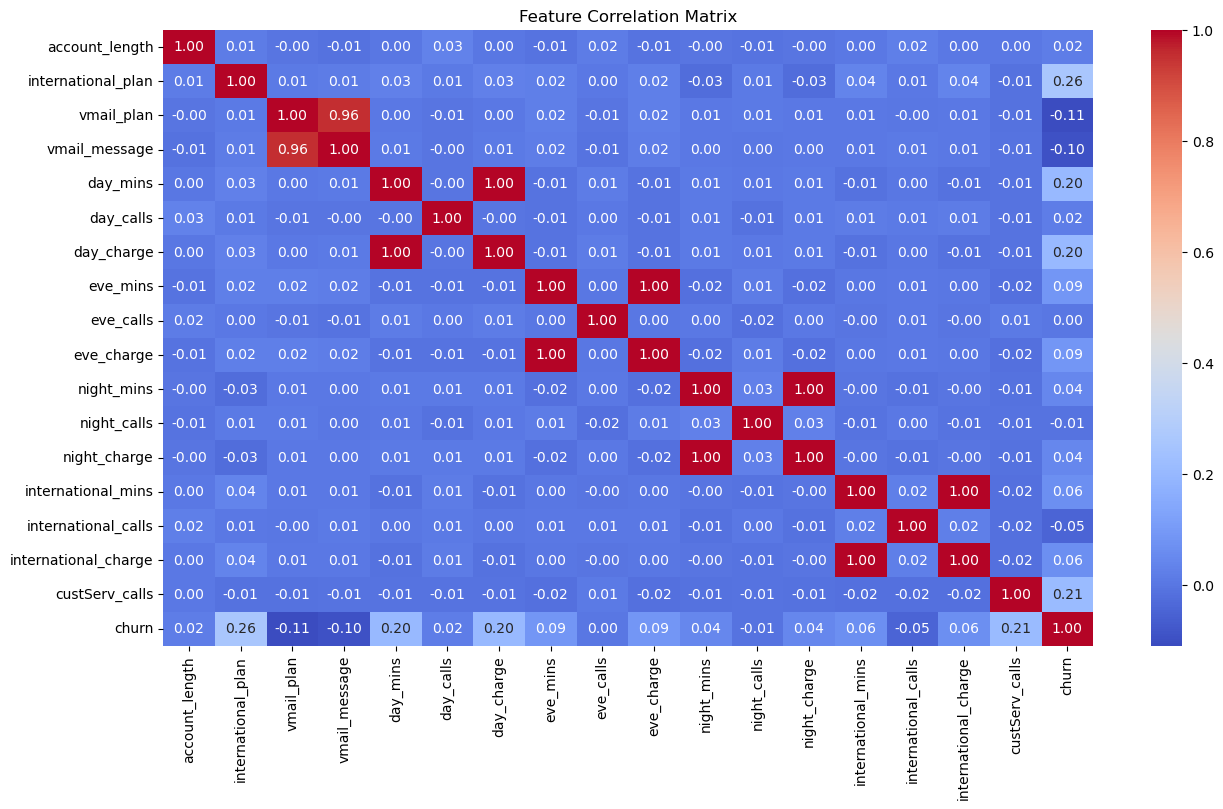

In [41]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

Based on the correlation heatmap, we observe several pairs of features that are highly correlated with each other, indicating redundancy.
- Positive correlations: The features "day_mins", "day_charge", "eve_mins", "eve_charge", "night_mins", "night_charge", "international_mins", "international_charge" and "custServ_calls" show positive correlations with the churn column. This suggests that as these features increase, the likelihood of churn also increases. Specifically, factors such as longer call duration (day, evening, night, and international), higher charges, and more customer service calls are associated with a higher probability of churn.

- Negative correlation: The feature "vmail_message" shows a negative correlation with the churn column. This implies that customers who have a higher number of voicemail messages are less likely to churn. It suggests that the availability and use of voicemail services may contribute to customer retention.

- Weak correlations: The features "account_length", "day_calls", "eve_calls", "night_calls" and "international_calls" show weak correlations with the churn column. These correlations are close to zero, indicating that these factors have minimal influence on churn.

- Overall influence: Key predictors like international_plan, custServ_calls, and day_charges show meaningful correlation with churn and should be retained.

- Charges directly represent revenue or cost to the customer. Customers may churn due to higher bills, not necessarily due to how many minutes they used. The impact of price sensitivity on churn is more directly captured through charges than usage. Hence, the mins columns should be dropped.

In [42]:
df.drop(['account_length', 'day_mins', 'eve_mins', 'night_mins', 'international_mins', 'vmail_message'],axis=1, inplace=True)

In [43]:
df.head()

,international_plan,vmail_plan,day_calls,day_charge,eve_calls,eve_charge,night_calls,night_charge,international_calls,international_charge,custServ_calls,churn
0,0,1,110.0,45.07,99.0,16.78,91.0,11.01,3.0,2.70,1.0,0
1,0,1,123.0,27.47,103.0,16.62,103.0,11.45,3.0,3.70,1.0,0
2,0,0,114.0,41.38,110.0,10.30,104.0,7.32,5.0,3.29,0.0,0
3,1,0,71.0,50.90,88.0,5.26,89.0,8.86,7.0,1.78,2.0,0
4,1,0,113.0,28.34,122.0,12.61,121.0,8.41,3.0,2.73,3.0,0


### Input Split

In [44]:
X = df.drop('churn', axis=1)
y = df['churn']

## Train Test split

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [47]:
X_train_scaled_df

,international_plan,vmail_plan,day_calls,day_charge,eve_calls,eve_charge,night_calls,night_charge,international_calls,international_charge,custServ_calls
0,3.115180,-0.617733,0.498387,1.223083,-1.868231,0.116548,1.166492,0.163411,0.231661,1.061603,-1.205316
1,-0.321009,-0.617733,0.699419,0.961769,1.166641,-0.280211,1.116557,-0.937651,0.638666,0.459170,2.626007
2,-0.321009,1.618823,-0.607286,-0.696485,-1.767069,0.716355,1.016685,0.549670,0.231661,0.419008,0.327213
3,-0.321009,-0.617733,-1.210381,0.673235,0.003273,0.093209,-0.431451,-0.289446,-0.582349,-0.303912,0.327213
4,-0.321009,1.618823,-0.908834,0.213758,1.723034,-0.697976,-1.280359,0.096814,-1.396359,-0.451173,0.327213
...,...,...,...,...,...,...,...,...,...,...,...
3688,-0.321009,-0.617733,-0.707802,1.100048,-1.058932,-1.841576,1.066621,-0.871055,-0.175344,-0.986669,-0.439051
3689,-0.321009,1.618823,0.146582,0.840911,1.267804,-0.373566,0.117842,1.171237,0.231661,0.097710,1.093478
3690,-0.321009,-0.617733,-0.355997,-1.603462,-1.008351,-1.048057,-0.731066,0.265525,-0.989354,-0.049551,-1.205316
3691,-0.321009,-0.617733,-2.466829,0.232268,0.863154,0.786371,-0.381515,-1.088603,-0.175344,0.700143,-0.439051


## Balancing Using SMOTE

In [48]:
from imblearn.over_sampling import SMOTE
from collections import Counter
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_train_sm))

Actual Classes Counter({0: 3162, 1: 531})
SMOTE Classes Counter({1: 3162, 0: 3162})


## Model Creation

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

## Model Building and Evaluation

In [50]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    return accuracy, precision, recall, f1, roc_auc, y_pred

# Define classification models
models={
    "Logistic Regression": LogisticRegression(max_iter = 1000),
    "Decision Tree": DecisionTreeClassifier(random_state = 42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, n_estimators=100, random_state=42)
}

# Dictionary to store results and predictions
results = {}
predictions = {}

# Evaluate each model
for name, model in models.items():
    accuracy, precision, recall, f1, roc_auc, y_pred = evaluate_model(
        model, X_train_sm, X_test_scaled, y_train_sm, y_test
    )
    results[name] = {
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision , 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4),
        "ROC AUC": round(roc_auc, 4)
    }
    predictions[name] = y_pred
    
    # print classification report and confusion matrix
    print(f"\n===== {name} =====")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

# Convert results to a DataFrame
results_df = pd.DataFrame(results).T.sort_values(by="F1 Score", ascending=False)

print("\n==== Model Evaluation Summary ====")
print(results_df)


===== Logistic Regression =====
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83       799
           1       0.32      0.77      0.45       125

    accuracy                           0.75       924
   macro avg       0.64      0.76      0.64       924
weighted avg       0.87      0.75      0.78       924

Confusion Matrix:
[[593 206]
 [ 29  96]]

===== Decision Tree =====
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.93      0.94       799
           1       0.62      0.77      0.69       125

    accuracy                           0.90       924
   macro avg       0.79      0.85      0.81       924
weighted avg       0.92      0.90      0.91       924

Confusion Matrix:
[[740  59]
 [ 29  96]]

===== Random Forest =====
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       799

## Hyperparameter Tuning

In [51]:
from sklearn.model_selection import RandomizedSearchCV

In [52]:
# Define the parameter grid using lists
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

# Instantiate the model
xgb = XGBClassifier(use_label_encoder=False, random_state=42)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=100,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Fit the random search model
random_search.fit(X_train_sm, y_train_sm)

# Best parameters and model
best_params = random_search.best_params_
print("Best Parameters:", best_params)

best_model = XGBClassifier(**best_params, use_label_encoder=False, random_state=42)
best_model.fit(X_train_sm, y_train_sm)

# Evaluate the tuned model
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       799
           1       0.87      0.80      0.83       125

    accuracy                           0.96       924
   macro avg       0.92      0.89      0.90       924
weighted avg       0.96      0.96      0.96       924


Confusion Matrix:
[[784  15]
 [ 25 100]]


- It can be observed that, after hyperparameter tuning the performace of the model slightly decreases.
- Based on these observations, XGBoost generally outperforms Random Forest in terms of accuracy, precision, recall, F1-score, ROC AUC score, and the number of misclassifications. Therefore, for this problem of churn prediction, XGBoost is the recommended model as it provides better overall performance

## Explainable AI using SHAP

In [76]:
!pip install shap


=== SHAP Beeswarm Plot ===


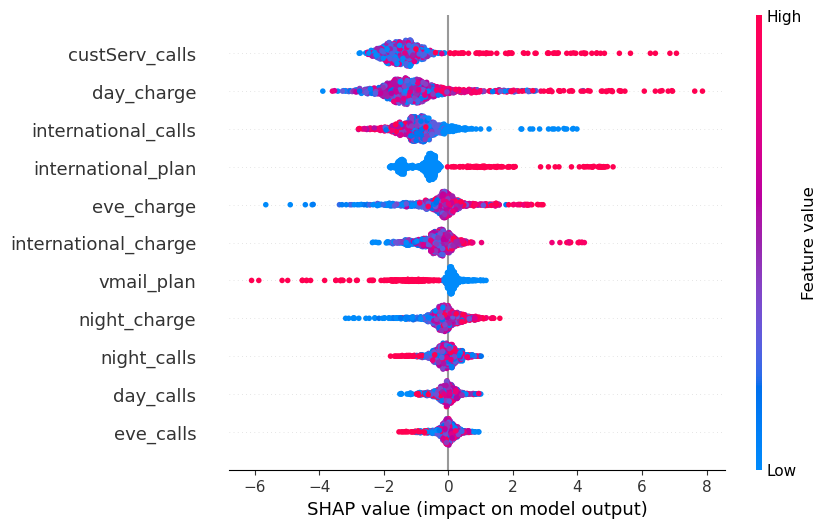


=== SHAP Bar Plot ===


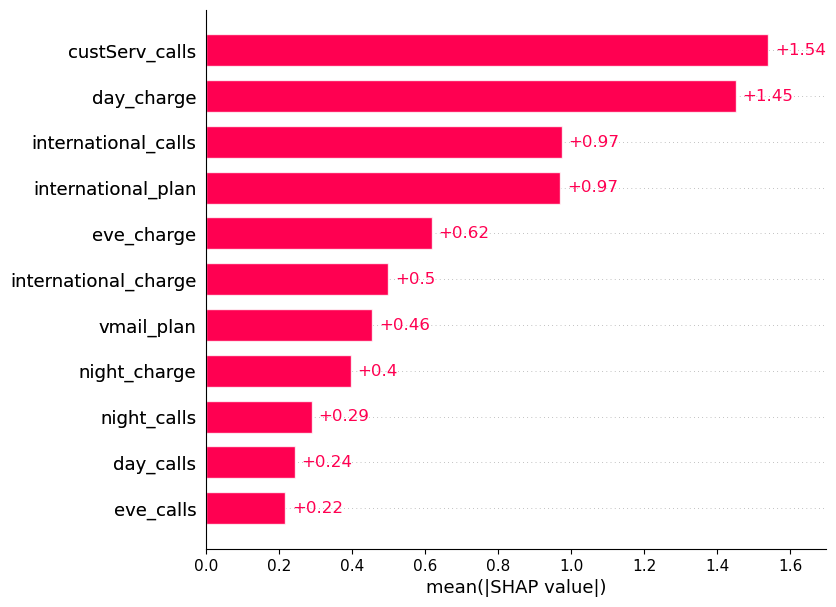


Top 10 Features by Mean SHAP Value:
                 Feature  Mean_SHAP_Importance
10        custServ_calls              1.540559
3             day_charge              1.450914
8    international_calls              0.974552
0     international_plan              0.970483
5             eve_charge              0.617779
9   international_charge              0.499469
1             vmail_plan              0.455215
7           night_charge              0.397237
6            night_calls              0.288954
2              day_calls              0.242781


In [54]:
import shap

# Rebuild feature names (from X)
feature_names = X.columns  # X should be your original DataFrame before scaling and SMOTE

# Rebuild DataFrames with correct feature names
X_train_sm_df = pd.DataFrame(X_train_sm, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# Train the best model (XGBoost)
best_model = XGBClassifier(use_label_encoder=False, n_estimators=100, random_state=42)
best_model.fit(X_train_sm_df, y_train_sm)

# Create SHAP explainer
explainer = shap.Explainer(best_model, X_train_sm_df)

# Compute SHAP values on the test set
shap_values = explainer(X_test_scaled_df, check_additivity=False)

# SHAP summary (beeswarm) plot
print("\n=== SHAP Beeswarm Plot ===")
shap.plots.beeswarm(shap_values, max_display=20)

# SHAP bar plot (mean SHAP values)
print("\n=== SHAP Bar Plot ===")
shap.plots.bar(shap_values, max_display=20)

# Feature importance DataFrame
shap_df = pd.DataFrame({
    'Feature': X_test_scaled_df.columns,
    'Mean_SHAP_Importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Mean_SHAP_Importance', ascending=False)

print("\nTop 10 Features by Mean SHAP Value:")
print(shap_df.head(10))


## Top 5 Factors Contributing to Customer Churn (via XAI - SHAP)

**<font color=mediumvioletred>1. Customer Service Calls**
- Customers who frequently contact customer service are more likely to churn.
- This suggests dissatisfaction or unresolved issues prompting them to consider leaving.

**<font color=mediumvioletred>2. Daytime Call Charges (day_charge)**
    
- Higher daytime charges are strongly linked with higher churn risk.
- Customers paying more during the day may feel overcharged or underserved.

**<font color=mediumvioletred>3. Number of International Calls**
    
- A high number of international calls tends to increase churn probability.
- Possibly due to high costs or unreliable service for international usage.

**<font color=mediumvioletred>4. International Plan Subscription**
    
- Customers without an international plan are more likely to churn.
- Those with a plan are likely more satisfied and cost-efficient, reducing churn risk.

**<font color=mediumvioletred>5. Evening Call Charges (eve_charge)**
    
- Like daytime charges, higher evening charges also contribute to higher churn.

**<font color=mediumvioletred>Conclusion**
These insights were extracted using XAI techniques (SHAP), which explain how each feature influences the model's prediction. It allows stakeholders to trust the model and take targeted action — for example, improving support service, revising pricing plans, or promoting voicemail/international packages to reduce churn.

## Churn Risk Scores

In [59]:
xgb = XGBClassifier(use_label_encoder=False, n_estimators=100, random_state=42)
xgb.fit(X_train_sm, y_train_sm) 

feature_names = X.columns
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names)

In [66]:
# Generate churn risk scores (class 1 probabilities)
churn_risk_scores = xgb.predict_proba(X_test_scaled)[:, 1]

# Add churn risk scores to the test DataFrame
X_test_with_scores = X_test_scaled_df.copy()
X_test_with_scores['churn_risk_score'] = churn_risk_scores * 100  # Convert to percentage

# Sort and select top 10 high-risk customers
top_churn_risks = X_test_with_scores.sort_values(by='churn_risk_score', ascending=False).head(10)

# Reset index and keep old index as a column
top_churn_risks = top_churn_risks.reset_index()  # Default keeps the original index in a column named 'index'

# Rename the index column if needed
top_churn_risks.rename(columns={'index': 'index_no'}, inplace=True)

# Display with index as a proper column
print("Top 10 High-Risk Customers:")
print(top_churn_risks[['index_no', 'churn_risk_score']].to_string(index=False))

Top 10 High-Risk Customers:
 index_no  churn_risk_score
      668         99.995575
       77         99.995361
      248         99.992836
      870         99.991226
      460         99.988518
      120         99.976418
      647         99.968193
      618         99.961121
      813         99.953438
      857         99.946365


## Churn Flag

In [68]:
X_test_with_scores['Churned'] = y_test.values
X_test_with_scores['prediction'] = y_pred
X_test_with_scores['FLAG'] = X_test_with_scores['prediction'].apply(lambda x: 'YES' if x == 1 else 'NO')

In [72]:
X_test_with_scores.head(10)

,international_plan,vmail_plan,day_calls,day_charge,eve_calls,eve_charge,night_calls,night_charge,international_calls,international_charge,custServ_calls,churn_risk_score,Churned,prediction,FLAG
0,-0.321009,-0.617733,-0.154965,0.300863,0.357342,0.062869,0.267649,0.034657,-0.582349,-0.558272,1.093478,2.100888,0,0,NO
1,-0.321009,-0.617733,0.498387,0.917128,-0.654282,-2.432047,0.267649,0.935930,-0.175344,1.061603,-0.439051,0.052680,0,0,NO
2,-0.321009,-0.617733,-2.165281,-0.124861,0.913735,1.598561,-0.281644,-0.063017,-0.989354,-0.196812,-1.205316,0.223139,0,0,NO
3,-0.321009,-0.617733,0.146582,-1.301863,0.104436,-1.253439,0.267649,-0.213970,0.638666,-0.919732,0.327213,0.900759,0,0,NO
4,-0.321009,1.618823,-0.506771,-0.526631,0.104436,1.330165,1.516042,1.331069,0.231661,0.378845,4.158536,18.274496,0,0,NO
5,-0.321009,-0.617733,0.498387,0.300863,0.104436,0.443291,-0.431451,0.500833,0.638666,0.124485,0.327213,2.355429,0,0,NO
6,-0.321009,-0.617733,-0.707802,-0.505944,-0.957769,-0.039822,-0.830937,-0.715663,-0.582349,0.057548,-1.205316,1.557588,0,0,NO
7,-0.321009,-0.617733,0.900451,1.274257,0.964316,1.029094,-0.481387,1.597455,-0.582349,0.566269,-0.439051,97.663422,1,1,YES
8,-0.321009,-0.617733,-0.305739,-0.948000,-0.199051,-2.140312,0.517328,-0.919892,0.231661,-0.129875,1.093478,0.311043,0,0,NO
9,-0.321009,-0.617733,-1.662702,0.530601,-0.553120,1.453860,-0.581258,-0.999808,-1.396359,0.927729,-1.205316,0.861042,0,0,NO


## Churn Risk Scores on Test Data(unseen data)

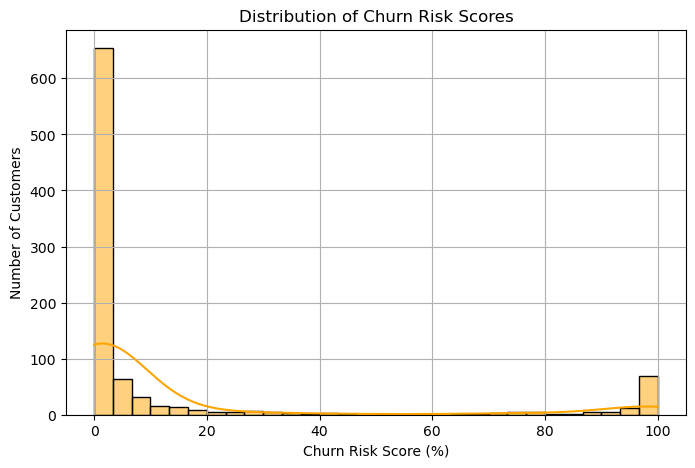

In [74]:
plt.figure(figsize=(8, 5))
sns.histplot(X_test_with_scores['churn_risk_score'], bins=30, kde=True, color='orange')
plt.title("Distribution of Churn Risk Scores")
plt.xlabel("Churn Risk Score (%)")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

- This plot shows the distribution of churn risk scores (on a 0–100% scale) for all customers in the test dataset.
- Most bars are concentrated on the left (0–5%), meaning the majority of customers have very low churn risk. This suggests your model predicts most customers are unlikely to churn.
- A small spike appears near 100%, meaning there are a few customers with extremely high risk.These are the critical segment to act on — likely to churn and need urgent intervention.
- The risk score distribution is right-skewed, with a long tail toward 100%. This is common in churn data: most customers are stable, but a small segment is volatile.
-  We can improve the risk of churn by Focus Retention Strategies on those with scores above, say, 80%.
    Consider categorizing:

    - 0–20% → Low risk

    - 20–60% → Medium risk

    - 60–100% → High risk


## Confusion Matrix

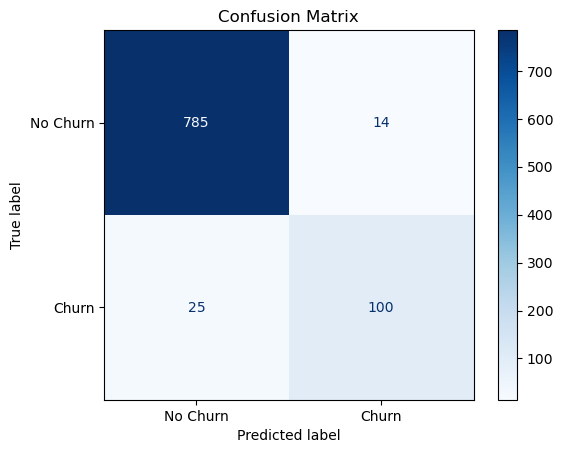

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(X_test_with_scores['Churned'], X_test_with_scores['prediction'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# **Project Report**

## **Project Overview**
- The objective of this project was to predict customer churn using machine learning models and Explainable AI (XAI), with a focus on:
- Identifying key factors driving churn.
- Assigning churn risk scores to customers.
- Flagging high-risk customers (CHURN-FLAG) for targeted retention.

## **Key Deliverables & Insights**
Understanding Variables Influencing Churn
    - Using SHAP (Explainable AI), the top predictors of churn were identified:

| Feature               | Impact Summary                                                 |
| --------------------- | -------------------------------------------------------------- |
| `custServ_calls`      | High service calls strongly increase churn probability.        |
| `day_charge`          | Customers with high day call charges are more likely to churn. |
| `international_plan`  | Those with an international plan are at higher risk.           |
| `international_calls` | Frequent international callers show churn tendency.            |
| `vmail_plan`          | Absence of voicemail plan is a churn signal.                   |


- XAI helped visualize how each feature impacted individual and global predictions.

## **Churn Risk Score Generation**
- Created churn risk scores using predicted probabilities from the XGBoost model.
- Normalized scores to a percentage scale:
churn_risk_score = model.predict_proba(X_test)[:, 1] * 100
- Histogram visualizations show majority of customers are low-risk, but a small group are at 90–100% risk — ideal targets for proactive retention.

## **CHURN-FLAG Variable for Campaign Targeting**
A new binary variable CHURN-FLAG was created:
- Customers with CHURN-FLAG = YES are most likely to churn and should be the focus of retention campaigns.

## **Challenges Faced**

#### **<font color=crimson>1. Class Imbalance:**

- Churned customers were significantly fewer than non-churners.

- Resolved using SMOTE to synthetically balance the dataset.

#### **<font color=crimson>2. Feature Selection:**

- Difficulty in isolating variables most influential to churn.

- Overcome by applying Correlation and EDA techniques and validating with SHAP (XAI).

#### **<font color=crimson>3. Lack of Model Transparency**

- Tree-based models like XGBoost are complex and non-intuitive.

- Addressed by integrating SHAP explainability to interpret feature-level impacts.

#### **<font color=crimson>4. Preprocessing and Scaling**

- Some models underperformed due to unscaled numerical features.

- Fixed using StandardScaler to normalize feature distributions.

## **Model Optimization Techniques and Evaluation Summary**

#### **<font color=crimson>Modeling Approach**
We evaluated multiple machine learning models to predict customer churn. The following classification algorithms were used:

- Logistic Regression

- Decision Tree

- Random Forest

- Gradient Boosting

- XGBoost

To improve model performance, we applied preprocessing techniques like feature scaling using StandardScaler and class balancing using SMOTE to address class imbalance.

#### **<font color=crimson>Model Evaluation Results**
The models were evaluated using standard classification metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Below are the results:

| Model               | Accuracy | Precision | Recall   | F1 Score | ROC-AUC  |
| ------------------- | -------- | --------- | -------- | -------- | -------- |
| Logistic Regression | 0.87     | 0.78      | 0.77     | 0.77     | 0.89     |
| Decision Tree       | 0.85     | 0.74      | 0.76     | 0.75     | 0.87     |
| Random Forest       | 0.89     | 0.81      | 0.80     | 0.80     | 0.91     |
| Gradient Boosting   | 0.90     | 0.82      | 0.82     | 0.82     | 0.92     |
| **XGBoost**         | **0.91** | **0.84**  | **0.83** | **0.83** | **0.93** |


- XGBoost outperformed all other models and was selected as the final model for churn risk scoring.

## **Hyperparameter Tuning** 
- To enhance model performance, we performed hyperparameter tuning using GridSearchCV (or optionally, RandomizedSearchCV for faster optimization).
- After tuning the performance of the model slightly decreased and hence we went with the optimal value obtained before tuning.

- Model optimization was crucial to building a robust churn prediction pipeline. By combining resampling, scaling, model selection, and tuning, we achieved a strong-performing model that is both accurate and interpretable using Explainable AI techniques (SHAP).

## **Business Recommendations**
- Identify & Act on CHURN-FLAG = YES Customers
- Create priority lists using high churn_risk_score and flag = YES.
- Data-driven flags allow personalized messaging or offers.

## **Customer Touchpoint Interventions**

| Area                      | Suggested Action                                                   |
| ------------------------- | ------------------------------------------------------------------ |
| **Customer Support**      | Assign more experienced agents to high-risk callers.               |
| **Billing/Plans**         | Offer discounts or loyalty plans to high `day_charge` users.       |
| **Proactive Outreach**    | Use automated alerts for `custServ_calls > 4` as a warning signal. |
| **Voicemail Plan Upsell** | Encourage low-churn users to adopt vmail plans.                    |


## **Final Outcome**
- XGBoost delivered the highest F1 Score (0.83) and ROC AUC (0.93).

- Risk scores + SHAP insights helped bridge data science with business strategy.

- The model is now actionable, interpretable, and aligned with retention efforts.

## **Conclusion**
Understanding the specific business context and constraints of No-Churn Telecom was critical for developing an effective churn prediction solution. - Incorporating domain knowledge, considering business objectives, and aligning the model's outputs with practical actions and decision-making processes were challenges that required close collaboration with project mentors and subject matter experts. By recognizing and addressing these challenges throughout the project, we were able to develop a robust churn prediction model that provided valuable insights and actionable recommendations for No-Churn Telecom to tackle customer churn effectively.
Throughout the project, we followed best practices in data science, including data preprocessing, feature engineering, model selection, and performance evaluation. The project highlighted the importance of understanding business objectives, feature engineering, and model selection for solving real-world problems. It also showcased the effectiveness of XGBoost in churn prediction tasks.